# IEEE 754 in Slow Motion

Computers don't know what "0.1" is. They only understand bits - and converting a decimal
number into a finite sequence of zeros and ones almost always involves rounding.

This notebook explores how that works using the **naive-ieee754** library, which stores
every bit explicitly so you can *watch* the rounding happen.

---

The core idea: just as we write large numbers in scientific notation (e.g. 6.022 × 10²³),
computers do the same thing in base 2. A floating-point number has three parts:

| Part | Float8 | Float16 | Float32 | Float64 | Role |
|------|--------|---------|---------|---------|------|
| **Sign** | 1 bit | 1 bit | 1 bit | 1 bit | 0 = positive, 1 = negative |
| **Exponent** | 4 bits | 5 bits | 8 bits | 11 bits | which power of 2 (stored with bias 7 / 15 / 127 / 1023) |
| **Mantissa** | 3 bits | 10 bits | 23 bits | 52 bits | the significant digits (plus the implicit leading "1.") |
| **Total** | 8 bits | 16 bits | 32 bits | 64 bits | |

The *bias* exists so that the exponent - which can be negative - is stored as an unsigned
integer. With n exponent bits, bias = 2^(n−1) − 1, giving a symmetric range around zero.

> **IEEE 754 convention:** all four formats share the same structure - sign bit, biased
> exponent, and mantissa with an implicit leading 1. Float16, Float32, and Float64 are
> officially defined by the IEEE 754 standard (binary16/32/64). Float8 follows the same
> conventions but is not part of the standard; it is included here for educational purposes.


In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

from naive_ieee754 import Float8, Float16, Float32, Float64, custom_float, number_line
from naive_ieee754.formats import (
    FLOAT8_FORMAT,
    FLOAT16_FORMAT,
    FLOAT32_FORMAT,
    FLOAT64_FORMAT,
)
from naive_ieee754.rounding import RoundingMode

## 1. Four ways to create a number

The library provides four constructors - all equivalent, all arriving at the same bit pattern:

- **`from_decimal`**: you supply the value, the library handles the rounding.
- **`from_bit_string`**: bit-by-bit control, useful for inspecting a specific pattern from the spec.
- **`from_raw_int`**: the hex representation you'd see in a debugger or memory dump.
- **Direct construction**: pass the three fields (sign, exponent, mantissa) as separate bit lists.

Let's create approximately 0.1 in Float32 all four ways:

In [2]:
a = Float32.from_decimal(0.1)
print(f"from_decimal(0.1)      → {a!r}")

b = Float32.from_bit_string("0 01111011 10011001100110011001101")
print(f"from_bit_string(...)   → {b!r}")

c = Float32.from_raw_int(0x3DCCCCCD)
print(f"from_raw_int(0x3DCC..) → {c!r}")

d = Float32(
    0,
    [0, 1, 1, 1, 1, 0, 1, 1],
    [1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1],
)
print(f"direct construction    → {d!r}")

from_decimal(0.1)      → Float32(sign=0 exp=[01111011] sig=[10011001100110011001101])
from_bit_string(...)   → Float32(sign=0 exp=[01111011] sig=[10011001100110011001101])
from_raw_int(0x3DCC..) → Float32(sign=0 exp=[01111011] sig=[10011001100110011001101])
direct construction    → Float32(sign=0 exp=[01111011] sig=[10011001100110011001101])


## 2. What's inside a float?

Let's dissect a simple Float32: **1.5**.

Why 1.5? Because it's exactly representable in binary: 1.5 = 1 + 2⁻¹ = **1.1₂**.
Unlike 0.1, there's no rounding surprise here.

In Float32, 1.5 looks like this:
- **Sign**: 0 (positive)
- **Stored exponent**: 127 (the bias) → represents 2⁰ = 1
- **Mantissa**: 10000...0 → with the implicit "1.", reads as 1.1₂ × 2⁰ = 1.5 ✓

The *implicit bit* trick: every normalized binary number starts with "1.",
so the format doesn't store that "1." - it's implied. This gives 24 effective bits
of precision from just 23 mantissa bits.

In [3]:
x = Float32.from_decimal(1.5)
print(f"value           : {x}")
print(f"repr            : {x!r}")
print(f"to_bit_string() : {x.to_bit_string()}")
print(f"to_hex()        : {x.to_hex()}")
print()
fields = x.to_fields_dict()
for k, v in fields.items():
    print(f"  {k:<22} = {v}")

value           : 1.5 (Float32)
repr            : Float32(sign=0 exp=[01111111] sig=[10000000000000000000000])
to_bit_string() : 0 01111111 10000000000000000000000
to_hex()        : 3FC00000

  sign                   = 0
  exponent_bits          = [0, 1, 1, 1, 1, 1, 1, 1]
  exponent_stored        = 127
  exponent_actual        = 0
  significand_bits       = [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  kind                   = normal
  decimal                = 1.5


## 3. Special values - when bits have personality

IEEE 754 reserves specific bit patterns for situations that aren't "normal numbers".
The general rule:

- **All-zero exponent** → zero or subnormal
- **All-ones exponent** → infinity or NaN


<img src="../special_cases.png" alt="IEEE 754 special cases" width="600"/>

*The four special cases mapped onto the sign / exponent / mantissa fields of a Float32.*

*Video reference: [How Floating Point Numbers Are Represented](https://youtu.be/bbkcEiUjehk?si=KLVZFbQXQtvJKN5R)*

In [18]:
specials = {
    "+Inf": Float32.positive_infinity(),
    "-Inf": Float32.negative_infinity(),
    "NaN": Float32.nan(),
    "+0": Float32.positive_zero(),
    "-0": Float32.negative_zero(),
    "smallest subnormal": Float32.from_raw_int(0x00000001),
}

for label, v in specials.items():
    print(
        f"  {label:<22} {str(v):<32}  kind={v.kind.value:<15}  bits={v.to_bit_string()}"
    )

  +Inf                   +Inf (Float32)                    kind=positive_inf     bits=0 11111111 00000000000000000000000
  -Inf                   -Inf (Float32)                    kind=negative_inf     bits=1 11111111 00000000000000000000000
  NaN                    NaN (Float32)                     kind=nan              bits=0 11111111 10000000000000000000000
  +0                     +0 (Float32)                      kind=positive_zero    bits=0 00000000 00000000000000000000000
  -0                     -0 (Float32)                      kind=negative_zero    bits=1 00000000 00000000000000000000000
  smallest subnormal     1.401298464324817e-45 (Float32)   kind=subnormal        bits=0 00000000 00000000000000000000001


### Subnormals: the buffer zone before zero

Without subnormals, there would be an abrupt jump from the smallest normal number
directly to zero (*sudden underflow*). Subnormals fill that gap gradually, at the
cost of fewer precision bits - a deliberate trade-off in the standard.

Note **−0** as well: mathematically identical to +0, but the sign bit is set.
This matters in some numerical contexts (e.g. `1/−0 = −∞` vs `1/+0 = +∞`).

In [5]:
n = Float32.from_decimal(3.14)
print(
    f"3.14 → is_normal={n.is_normal()}  is_subnormal={n.is_subnormal()}  "
    f"is_nan={n.is_nan()}  is_inf={n.is_inf()}"
)

3.14 → is_normal=True  is_subnormal=False  is_nan=False  is_inf=False


## 4. Arithmetic with Python operators

The library overloads `+`, `−`, `*`, `/`, unary negation, and `abs()`.
The result is always rounded back to the original format.

In [6]:
p = Float32.from_decimal(1.0)
q = Float32.from_decimal(2.0)

print(f"p = {p}   q = {q}")
print(f"p + q = {p + q}")
print(f"p - q = {p - q}")
print(f"p * q = {p * q}")
print(f"p / q = {p / q}")
print(f"-p    = {-p}")
print(f"|p-q| = {abs(p - q)}")

p = 1.0 (Float32)   q = 2.0 (Float32)
p + q = 3.0 (Float32)
p - q = -1.0 (Float32)
p * q = 2.0 (Float32)
p / q = 0.5 (Float32)
-p    = -1.0 (Float32)
|p-q| = 1.0 (Float32)


## 5. Step-by-step arithmetic - the educational core

The `.add()`, `.mul()`, `.div()`, and `.sqrt()` methods do the same thing as the operators,
but return an object with the **full computation trace**: every intermediate step,
the bits discarded during rounding, and a precision report.

Let's see what happens in 0.1 + 0.2:

In [7]:
a = Float32.from_decimal(0.1)
b = Float32.from_decimal(0.2)

res = a.add(b)
print(res.explain())
print("\n--- Precision report ---")
print(res.precision_report())

Operation: add
Precision lost: True
Flags: inexact

Step 1: [input] Inputs: a = 0.10000000149011612 (0 01111011 10011001100110011001101), b = 0.20000000298023224 (0 01111100 10011001100110011001101)
    a_decimal: 0.10000000149011612
    b_decimal: 0.20000000298023224
    a_bits: 0 01111011 10011001100110011001101
    b_bits: 0 01111100 10011001100110011001101

Step 2: [special_check] No special case; using exact integer addition.
    triggered: none

Step 3: [add_significands] Aligned significands exactly and added signed integers.
    common_exponent: -27
    a_integer: 13421773
    b_integer: 26843546
    sum_integer: 40265319

Step 4: [round] Rounded exact result with rne.
    flags: ['inexact']

Step 5: [result] Result: 0.30000001192092896 (Float32)
    decimal: 0.30000001192092896
    bit_string: 0 01111101 00110011001100110011010

Result: 0.30000001192092896 (Float32)

--- Precision report ---
  exact (Python float64): 0.30000000447034836
  represented (Float32): 0.3000000119209

In [8]:
print("--- √2 ---")
two = Float32.from_decimal(2.0)
sqrt_res = two.sqrt()
print(sqrt_res.explain())

--- √2 ---
Operation: sqrt
Precision lost: True
Flags: inexact

Step 1: [input] Input: a = 2.0 (0 10000000 00000000000000000000000)
    a_decimal: 2.0
    a_bits: 0 10000000 00000000000000000000000

Step 2: [special_check] No special case; computing integer square root.
    triggered: none

Step 3: [decode] Decoded exact value; adjusted to even exponent.
    significand: 8388608
    exponent: -22
    half_exponent: -11
    value: 8388608 × 2^-22

Step 4: [integer_sqrt] Computed integer square root with guard bits.
    guard_bits_p: 50
    q: 3260954456333195553
    remainder: 569968869703780799
    exact: False

Step 5: [round] Rounded with rne.
    flags: ['inexact']

Step 6: [result] Result: 1.4142135381698608 (Float32)
    decimal: 1.4142135381698608
    bit_string: 0 01111111 01101010000010011110011

Result: 1.4142135381698608 (Float32)


## 6. Why $0.1 + 0.2 \neq 0.3$?

The most famous floating-point question. The short answer:
0.1, 0.2, and 0.3 are repeating fractions in binary - just like 1/3 is in decimal.
Each one is already rounded when stored. The sum of two rounded values
rarely matches the third rounded value.

Let's compare the behavior across different formats, from most to least precise:

In [9]:
for Fmt in (Float64, Float32, Float16, Float8):
    f01 = Fmt.from_decimal(0.1)
    f02 = Fmt.from_decimal(0.2)
    f03 = Fmt.from_decimal(0.3)
    total = f01 + f02

    print(f"\n{Fmt.__name__}:")
    print(f"  0.1 stored as  {f01.to_decimal()!r}  ({f01.to_bit_string()})")
    print(f"  0.2 stored as  {f02.to_decimal()!r}  ({f02.to_bit_string()})")
    print(f"  0.3 stored as  {f03.to_decimal()!r}  ({f03.to_bit_string()})")
    print(f"  0.1+0.2      = {total.to_decimal()!r}  ({total.to_bit_string()})")
    print(f"  0.1+0.2 == 0.3? → {total == f03}")


Float64:
  0.1 stored as  0.1  (0 01111111011 1001100110011001100110011001100110011001100110011010)
  0.2 stored as  0.2  (0 01111111100 1001100110011001100110011001100110011001100110011010)
  0.3 stored as  0.3  (0 01111111101 0011001100110011001100110011001100110011001100110011)
  0.1+0.2      = 0.30000000000000004  (0 01111111101 0011001100110011001100110011001100110011001100110100)
  0.1+0.2 == 0.3? → False

Float32:
  0.1 stored as  0.10000000149011612  (0 01111011 10011001100110011001101)
  0.2 stored as  0.20000000298023224  (0 01111100 10011001100110011001101)
  0.3 stored as  0.30000001192092896  (0 01111101 00110011001100110011010)
  0.1+0.2      = 0.30000001192092896  (0 01111101 00110011001100110011010)
  0.1+0.2 == 0.3? → True

Float16:
  0.1 stored as  0.0999755859375  (0 01011 1001100110)
  0.2 stored as  0.199951171875  (0 01100 1001100110)
  0.3 stored as  0.300048828125  (0 01101 0011001101)
  0.1+0.2      = 0.2998046875  (0 01101 0011001100)
  0.1+0.2 == 0.3? → Fals

> **Float8 curiosity:** with only 8 bits, 0.1, 0.2, and 0.3 are rounded so far from
> their original values that sometimes `0.1 + 0.2 == 0.3` returns `True`
> - not because the arithmetic got "more precise": it's because all three fell into
> the same rounding hole. Watch out for happy coincidences.

## 7. Rounding modes

When the result of an operation doesn't fit exactly in the available bits,
IEEE 754 defines five strategies:

| Mode | Behavior |
|------|----------|
| `round_half_to_even` | rounds to the nearest even neighbor (*banker's rounding*) - **IEEE 754 default** |
| `round_half_up` | rounds half-way cases always up |
| `round_toward_zero` | truncates (equivalent to `floor` for positives) |
| `round_toward_positive_inf` | always rounds up (*ceiling*) |
| `round_toward_negative_inf` | always rounds down (*floor*) |

The default `round_half_to_even` minimizes cumulative bias over long sequences.
Let's see how each mode affects 1/3:

In [10]:
a = Float32.from_decimal(1.0)
b = Float32.from_decimal(3.0)

for mode in RoundingMode:
    r = a.div(b, rounding=mode)
    print(f"  1/3 with {mode.value:<35} → {r.result.to_decimal()!r}")

  1/3 with rne                                 → 0.3333333432674408
  1/3 with rtz                                 → 0.3333333134651184
  1/3 with rpi                                 → 0.3333333432674408
  1/3 with rni                                 → 0.3333333134651184


## 8. Custom formats

`custom_float()` lets you create formats with any combination of exponent and mantissa bits.
Useful for studying the trade-off between *range* (controlled by the exponent)
and *precision* (controlled by the mantissa).

A format with few bits is instructive: you can inspect *all* representable values
and see how they spread across the number line.

In [11]:
Mini = custom_float(exponent_bits=4, significand_bits=3)
print(f"Mini = custom_float(4e + 3sig)  →  {Mini.FORMAT}")

m = Mini.from_decimal(1.5)
print(f"Mini(1.5) = {m!r}  →  decimal={m.to_decimal()}")

print("\nSame value (0.1) stored in different formats:")
for Fmt in (Float8, Float16, Float32, Float64):
    v = Fmt.from_decimal(0.1)
    print(f"  {Fmt.__name__:<8}  0.1 → {v.to_decimal()!r}")

Mini = custom_float(4e + 3sig)  →  FloatFormat(name='Custom(4e+3sig)', exponent_bits=4, significand_bits=3)
Mini(1.5) = Custom(4e+3sig)(sign=0 exp=[0111] sig=[100])  →  decimal=1.5

Same value (0.1) stored in different formats:
  Float8    0.1 → 0.1015625
  Float16   0.1 → 0.0999755859375
  Float32   0.1 → 0.10000000149011612
  Float64   0.1 → 0.1


## 9. The number line - where floats actually live

Floating-point numbers are **not uniformly distributed** on the number line.
They cluster near zero and grow increasingly sparse as values get larger.

Why? The exponent "scales" the grid, but the grid itself (the mantissa) always has
the same density. Each power of two contains the same number of representable values,
but they cover an interval twice as wide - so they're twice as sparse.

These intervals between consecutive powers of two are called **binades**.

### Float8 - three perspectives

Float8  [−∞, +∞)  —  ∞ representable  —  239 plotted  (exact)
Float8  [−∞, +∞)  —  ∞ representable  —  239 plotted  (exact)
Float8  [1, 8)  —  24 representable  —  24 plotted  (exact)


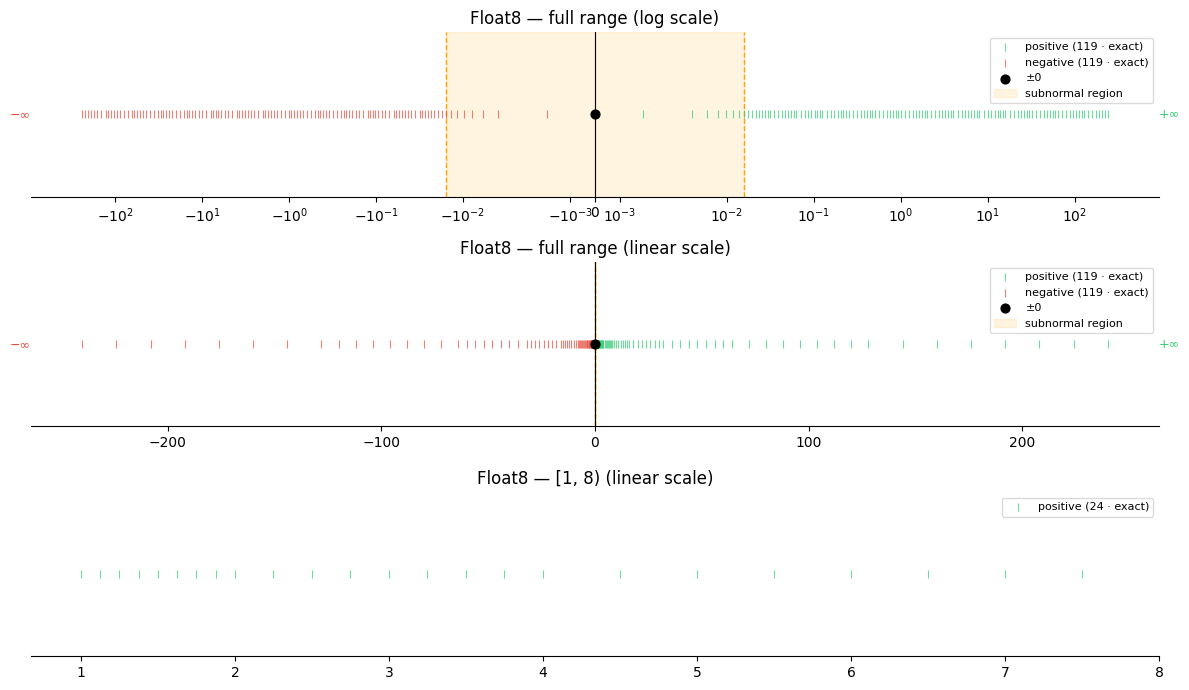

In [12]:
fig1, (ax1a, ax1b, ax1c) = plt.subplots(3, 1, figsize=(12, 7))
number_line(FLOAT8_FORMAT, ax=ax1a, log_scale=True)
ax1a.set_title("Float8 - full range (log scale)")
number_line(FLOAT8_FORMAT, ax=ax1b, log_scale=False)
ax1b.set_title("Float8 - full range (linear scale)")
number_line(FLOAT8_FORMAT, ax=ax1c, log_scale=False, x_range=(1, 8))
ax1c.set_xlim(right=8)
ax1c.set_title("Float8 - [1, 8) (linear scale)")
fig1.tight_layout()
plt.show()

The log scale (top) makes the grid look uniform - that is the mantissa doing its job: equal spacing on a log axis means equal *relative* precision across the full range.

The linear scale (middle) makes the clustering near zero visible.

The zoom into [1, 8) (bottom) is worth pausing on. Notice the gaps between consecutive values grow as you move right. Each binade - the interval [2^n, 2^(n+1)) - holds exactly the same number of representable values, but covers twice the width. So [1, 2) is twice as dense as [2, 4), which is twice as dense as [4, 8). This is not a coincidence: it follows directly from the exponent increment stepping the grid, while the mantissa count stays fixed.

### Float16 - same analysis, higher resolution

Float16  [−∞, +∞)  —  ∞ representable  —  63,487 plotted  (exact)
Float16  [−∞, +∞)  —  ∞ representable  —  63,487 plotted  (exact)
Float16  [1, 8)  —  3,072 representable  —  3,072 plotted  (exact)


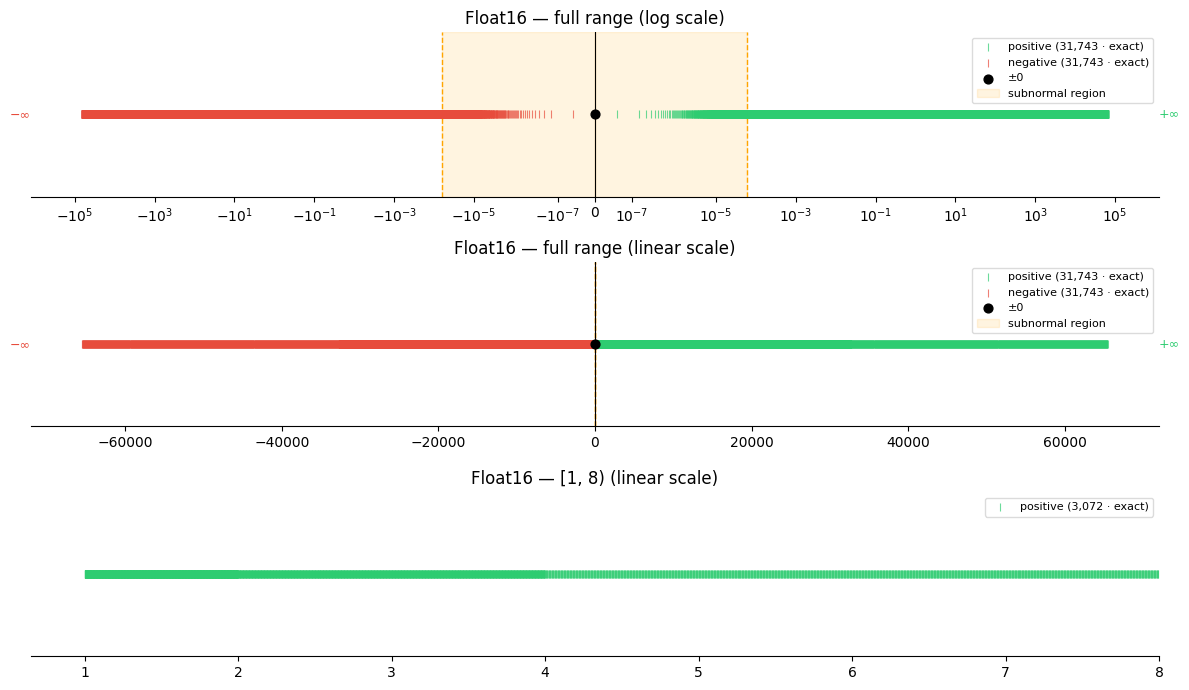

In [13]:
fig2, (ax2a, ax2b, ax2c) = plt.subplots(3, 1, figsize=(12, 7))
number_line(FLOAT16_FORMAT, ax=ax2a, log_scale=True)
ax2a.set_title("Float16 - full range (log scale)")
number_line(FLOAT16_FORMAT, ax=ax2b, log_scale=False)
ax2b.set_title("Float16 - full range (linear scale)")
number_line(FLOAT16_FORMAT, ax=ax2c, log_scale=False, x_range=(1, 8))
ax2c.set_xlim(right=8)
ax2c.set_title("Float16 - [1, 8) (linear scale)")
fig2.tight_layout()
plt.show()

The same pattern holds for Float16. The zoom into [1, 8) confirms it: [1, 2) is twice as dense as [2, 4), twice as dense as [4, 8). More mantissa bits means more values per binade - but the density halving between consecutive binades is structural, not incidental.

### Float16 - the subnormal region in detail

Subnormals live between zero and the smallest normal number (`min_positive_normal`).
Unlike normals (logarithmic distribution), subnormals are distributed *linearly*
- the grid no longer scales.

Float16  [-6.10352e-05, 6.10352e-05)  —  2,049 representable  —  2,048 plotted  (exact)
Float16  [0, 6.10352e-05)  —  1,025 representable  —  1,024 plotted  (exact)
Float16  [0, 6.10352e-05)  —  1,025 representable  —  1,024 plotted  (exact)


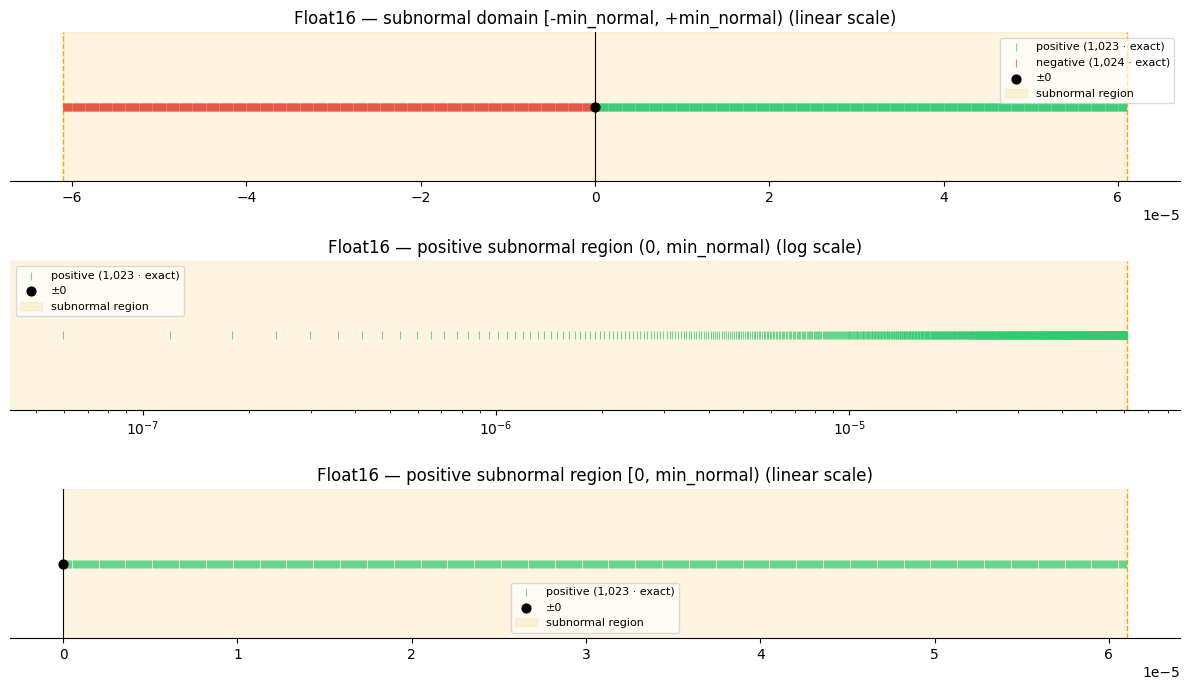

In [14]:
fig3, axes3 = plt.subplots(3, 1, figsize=(12, 7))
number_line(
    FLOAT16_FORMAT,
    ax=axes3[0],
    log_scale=False,
    x_range=(-FLOAT16_FORMAT.min_positive_normal, FLOAT16_FORMAT.min_positive_normal),
)
axes3[0].set_title(
    "Float16 - subnormal domain [-min_normal, +min_normal) (linear scale)"
)
number_line(
    FLOAT16_FORMAT,
    ax=axes3[1],
    log_scale=True,
    x_range=(0, FLOAT16_FORMAT.min_positive_normal),
)
axes3[1].set_title("Float16 - positive subnormal region (0, min_normal) (log scale)")
number_line(
    FLOAT16_FORMAT,
    ax=axes3[2],
    log_scale=False,
    x_range=(0, FLOAT16_FORMAT.min_positive_normal),
)
axes3[2].set_title("Float16 - positive subnormal region [0, min_normal) (linear scale)")
fig3.tight_layout()
plt.show()

### Consecutive binades: Float8 vs Float16

Same interval width (delta = 1), different formats.
Notice how Float16 packs far more values into the same space:

Float8  [1, 2)  —  8 representable  —  8 plotted  (exact)
Float8  [2, 3)  —  4 representable  —  4 plotted  (exact)
Float8  [4, 5)  —  2 representable  —  2 plotted  (exact)
Float16  [1, 2)  —  1,024 representable  —  1,024 plotted  (exact)
Float16  [2, 3)  —  512 representable  —  512 plotted  (exact)
Float16  [4, 5)  —  256 representable  —  256 plotted  (exact)


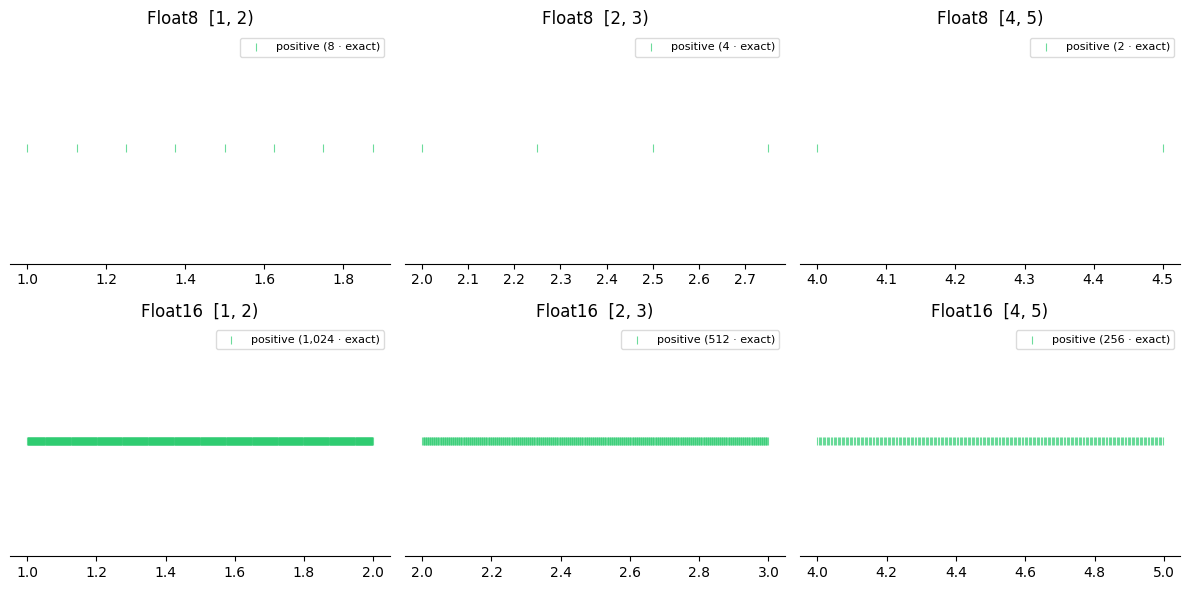

In [15]:
_delta = 1
_fig4_formats = [FLOAT8_FORMAT, FLOAT16_FORMAT]
_fig4_ranges = [(1, 1 + _delta), (2, 2 + _delta), (4, 4 + _delta)]
fig4, axes4 = plt.subplots(2, 3, figsize=(12, 6))
for row, fmt in enumerate(_fig4_formats):
    for col, x_range in enumerate(_fig4_ranges):
        number_line(fmt, ax=axes4[row, col], log_scale=False, x_range=x_range)
        axes4[row, col].set_title(f"{fmt.name}  [{x_range[0]}, {x_range[1]})")
fig4.tight_layout()
plt.show()

### Float32 vs Float64 - the precision gap under a microscope

To see the difference between Float32 and Float64, we need very narrow windows
(delta = 10⁻⁶). Within that interval:
- Float32 has only a handful of representable values
- Float64 has tens of thousands

> This plot may take a few seconds for Float64 -
> the high `samples_per_exponent` ensures no value is missed.

Float32  [1, 1)  —  9 representable  —  9 plotted  (exact in range)
Float32  [2, 2)  —  5 representable  —  5 plotted  (exact in range)
Float32  [4, 4)  —  3 representable  —  3 plotted  (exact in range)
Float64  [1, 1)  —  4.504e+09 representable  —  1,074 plotted  (sampled — 1 in every 4,194,304 significand values)
Float64  [2, 2)  —  2.252e+09 representable  —  537 plotted  (sampled — 1 in every 4,194,304 significand values)
Float64  [4, 4)  —  1.126e+09 representable  —  269 plotted  (sampled — 1 in every 4,194,304 significand values)


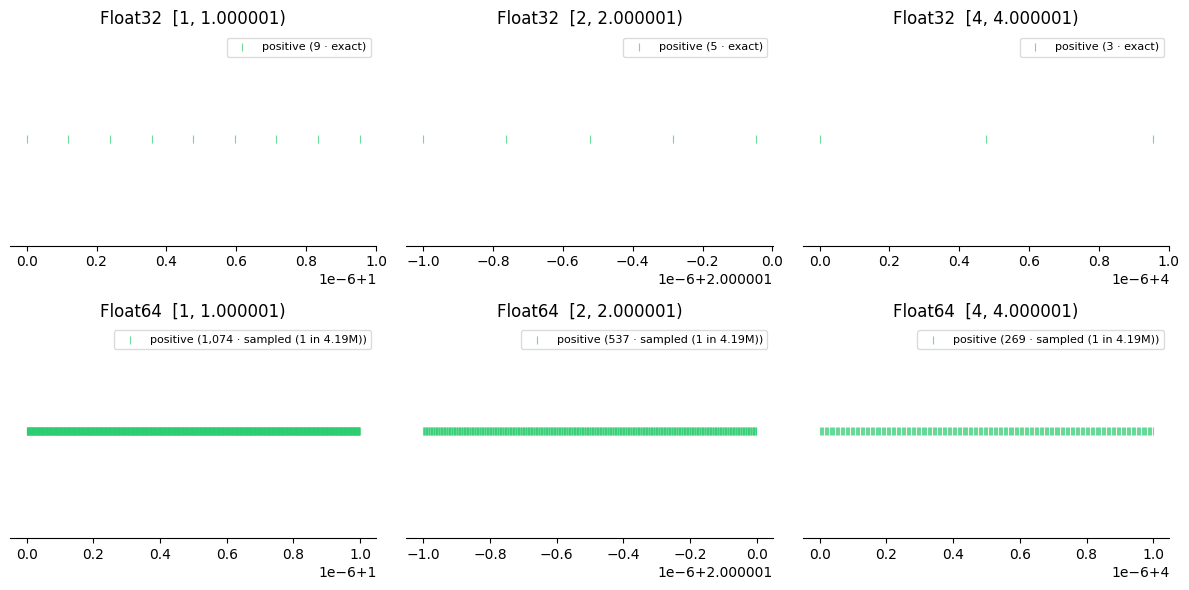

In [ ]:
_delta = 1e-6
_fig5_formats = [FLOAT32_FORMAT, FLOAT64_FORMAT]
_fig5_ranges = [(1, 1 + _delta), (2, 2 + _delta), (4, 4 + _delta)]
fig5, axes5 = plt.subplots(2, 3, figsize=(12, 6))
for row, fmt in enumerate(_fig5_formats):
    for col, x_range in enumerate(_fig5_ranges):
        number_line(
            fmt,
            samples_per_exponent=2**30,
            ax=axes5[row, col],
            log_scale=False,
            x_range=x_range,
        )
        axes5[row, col].set_title(f"{fmt.name}  [{x_range[0]}, {x_range[1]})")
fig5.tight_layout()
plt.show()

---

## Summary

What we covered:

1. **Floats are always approximations** - except for powers of 2 and simple combinations of them.
2. **The distribution is logarithmic**: constant *relative* precision, not absolute.
3. **Special cases exist out of necessity**: ±∞ and NaN let computation continue after overflow or invalid operations.
4. **Subnormals trade precision for gradual underflow** - a deliberate choice in the standard.
5. **More bits = more precision + wider range**, but never exact representation of all reals.

The `naive-ieee754` library makes every one of these points observable, bit by bit.